<a href="https://colab.research.google.com/github/HetP23/AERE5920-Data-Analytics-and-Machine-Learning-for-Cyber-Physical-Systems-Applications/blob/main/ME5920HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 2.1 Images

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset

transform = transforms.ToTensor()

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

indices = torch.randperm(len(test_dataset))[:1000]
test_subset = Subset(test_dataset, indices)

image, label = test_subset[0]

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 548kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.61MB/s]


In [ ]:
labels = [test_subset[i][1] for i in range(len(test_subset))]

labels = torch.tensor(labels)

class_counts = torch.bincount(labels, minlength=10)

tensor([ 93,  96, 114,  85,  97,  95, 102,  95, 106, 117])


Text(0, 0.5, 'Count in Class')

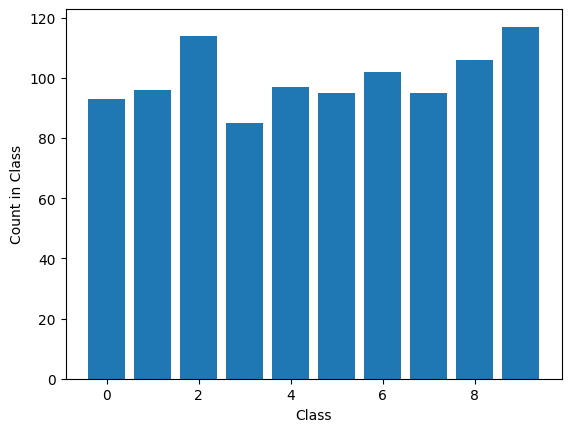

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(range(10), class_counts)
plt.xlabel('Class')
plt.ylabel('Count in Class')

In [ ]:
from einops import rearrange

images = torch.stack([test_subset[i][0] for i in range(len(test_subset))])

batch_image = rearrange(images, '(b n) c h w -> b n c h w', n=25)

print(batch_image.shape)

torch.Size([40, 25, 1, 28, 28])


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Text(0.5, 0, 'Intensity')

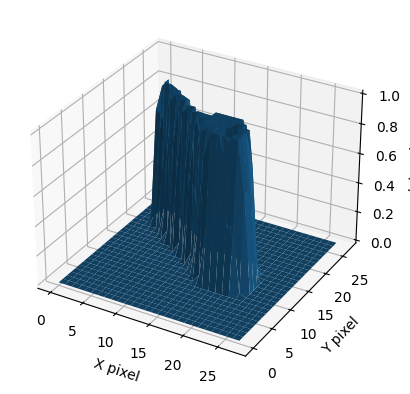

In [ ]:
index = torch.randint(0, len(test_subset), (1,)).item()

image, label = test_subset[index]

image = image.squeeze()

x = torch.arange(28)
y = torch.arange(28)
xx, yy = torch.meshgrid(x,y)
zz = image

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx.numpy(), yy.numpy(), zz.numpy())

ax.set_xlabel('X pixel')
ax.set_ylabel('Y pixel')
ax.set_zlabel('Intensity')

Problem 2.2 Time Series

Text(50.722222222222214, 0.5, 'Hour of Day')

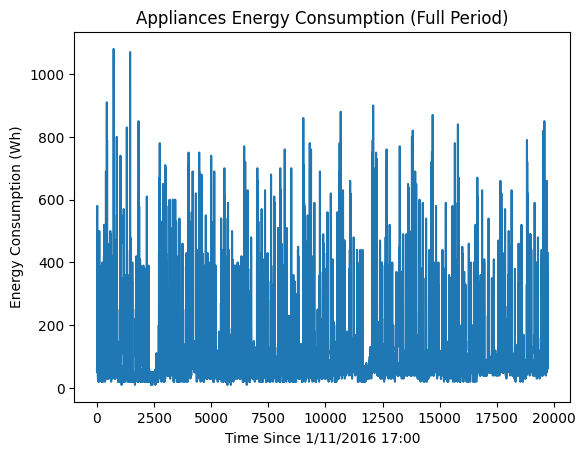

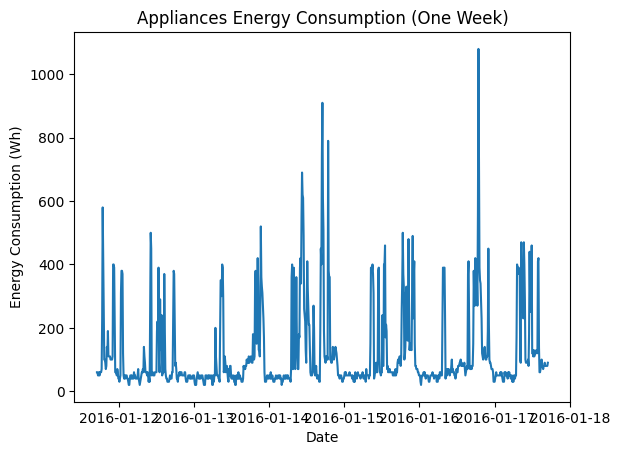

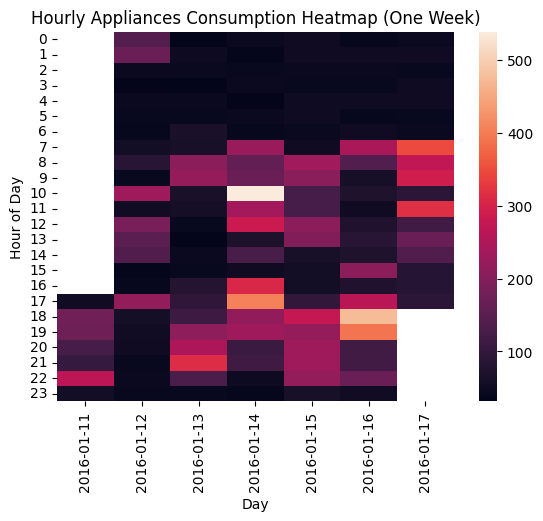

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

energy_data = pd.read_csv("energydata_complete.csv")

energy_data['date'] = pd.to_datetime(energy_data['date'])

plt.figure()
plt.plot(energy_data['date'].index, energy_data['Appliances'])
plt.title("Appliances Energy Consumption (Full Period)")
plt.xlabel("Time Since 1/11/2016 17:00")
plt.ylabel("Energy Consumption (Wh)")

target_date = pd.to_datetime("2016-01-17 17:00:00")

matching_indices = energy_data[energy_data['date'] == target_date].index

if not matching_indices.empty:
    one_week_idx = matching_indices[0]
else:
    print(f"Warning: Target date '{target_date}' not found. Plotting full 'Appliances' series.")
    one_week_idx = len(energy_data) - 1

one_week_df = energy_data.loc[0:one_week_idx].copy()
one_week_df = one_week_df.set_index('date')

plt.figure()
plt.plot(one_week_df.index, one_week_df['Appliances'])
plt.title("Appliances Energy Consumption (One Week)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

one_week_df['hour'] = one_week_df.index.hour
one_week_df['day'] = one_week_df.index.date

heatmap_data = one_week_df.pivot_table(
    values='Appliances',
    index='hour',
    columns='day',
    aggfunc='mean'
)

plt.figure()
sns.heatmap(heatmap_data)
plt.title("Hourly Appliances Consumption Heatmap (One Week)")
plt.xlabel("Day")
plt.ylabel("Hour of Day")

correlation value:              Appliances       NSM  Press_mm_hg
Appliances     1.000000  0.217152    -0.034885
NSM            0.217152  1.000000    -0.006199
Press_mm_hg   -0.034885 -0.006199     1.000000
Comments on the Correlation: 

Correlation between 2 values is typically between -1 and +1, where the closer the value is to +/-1
the stronger the correlation between the 2 variables. Based on the values given below, there is a stronger relationship between
NSM and the energy consumption than the relationship between the Pressure and energy consumption. It is still a relatively weak 
relationship because the correlation value between NSM and energy consumption is only 0.2172




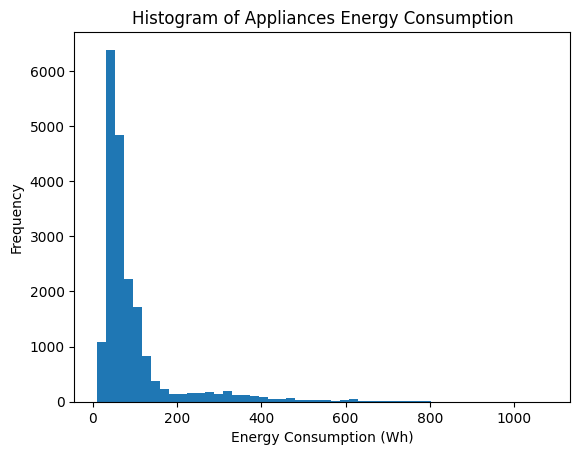

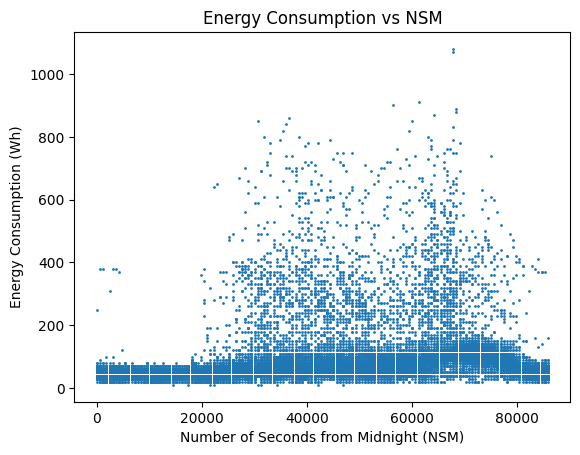

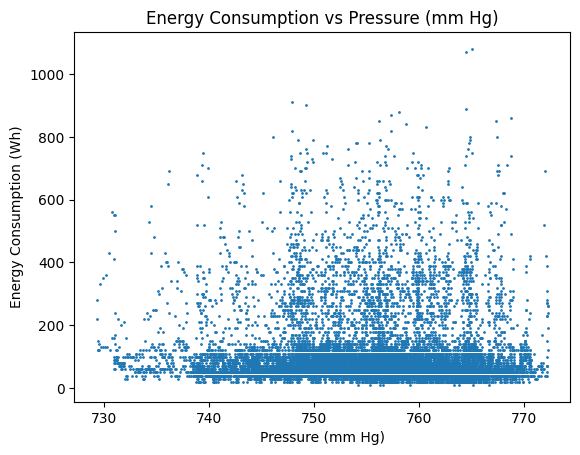

In [60]:
plt.figure()
plt.hist(energy_data['Appliances'], bins=50)

energy_data['NSM'] = (
    energy_data['date'].dt.hour * 3600 +
    energy_data['date'].dt.minute * 60 +
    energy_data['date'].dt.second
)
plt.title("Histogram of Appliances Energy Consumption")
plt.xlabel("Energy Consumption (Wh)")
plt.ylabel("Frequency")

plt.figure()
plt.scatter(energy_data['NSM'], energy_data['Appliances'], s=1)
plt.title("Energy Consumption vs NSM")
plt.xlabel("Number of Seconds from Midnight (NSM)")
plt.ylabel("Energy Consumption (Wh)")

plt.figure()
plt.scatter(energy_data['Press_mm_hg'], energy_data['Appliances'], s=1)
plt.title("Energy Consumption vs Pressure (mm Hg)")
plt.xlabel("Pressure (mm Hg)")
plt.ylabel("Energy Consumption (Wh)")

correlation = energy_data[['Appliances', 'NSM', 'Press_mm_hg']].corr()
print(f"correlation value: {correlation}")

print("""Comments on the Correlation:

Correlation between 2 values is typically between -1 and +1, where the closer the value is to +/-1
the stronger the correlation between the 2 variables. Based on the values given below, there is a stronger relationship between
NSM and the energy consumption than the relationship between the Pressure and energy consumption. It is still a relatively weak
relationship because the correlation value between NSM and energy consumption is only 0.2172

""")

Problem 2.3 Multi-Variate

In [ ]:
import numpy as np
from scipy.stats import kurtosis, skew

frequency, aoa, chord, vel, disp, spl = np.loadtxt("airfoil_self_noise.dat").T

dB_mean = np.mean(spl)
dB_std = np.std(spl)
dB_median = np.median(spl)
dB_kurtosis = kurtosis(spl)
dB_skew = skew(spl, bias=False)
dB_range = np.max(spl) - np.min(spl)

print("Mean: ", dB_mean)
print("St Dev: ", dB_std)
print("Median: ", dB_median)
print("Kurtosis: ", dB_kurtosis)
print("Skew: ", dB_skew)
print("Range: ", dB_range)

Mean:  124.83594278110448
St Dev:  6.896361277488791
Median:  125.721
Kurtosis:  -0.31713243440698324
Skew:  -0.4189521877346854
Range:  37.607


Problem 3.1 Image Pre-Processing and Transformation

In [ ]:
import random
import os
from pathlib import Path
from PIL import Image

!mkdir processed_images
cwd = Path('.')
img_files = [f for f in os.listdir(cwd) if f.endswith((".png"))]

transform = transforms.Compose([transforms.RandomAffine(
    degrees=30,
    translate=(0.3, 0.3),
    scale=(0.8, 1.2)
), transforms.RandomPerspective(
    distortion_scale=0.2,
    p=0.5
), transforms.RandomRotation(
    degrees=30
)])

img_count = 0
while img_count < 100:
  img = random.choice(img_files)
  image = Image.open(img)
  transformed_image = transform(image)
  transformed_image.save(f"processed_images/transformed_{img_count}.png")
  img_count = img_count + 1

In [ ]:
!mkdir local_patch_imgs

patch_size = 28
patch_list = []
for trans_img_filename in os.listdir(cwd / "processed_images"):
  img_path = cwd / "processed_images" / trans_img_filename
  # Open the image once outside the inner loop
  image_obj = Image.open(img_path)
  w, h = image_obj.size
  for i in range(25):
    x = random.randint(0, w - patch_size)
    y = random.randint(0, h - patch_size)

    patch = image_obj.crop((x, y, x + patch_size, y + patch_size))
    patch.save(f"local_patch_imgs/patch_{trans_img_filename}_{i}.png")
    patch_list.append(patch)

patch_list = np.array(patch_list)
print(patch_list.shape)

mkdir: cannot create directory ‘local_patch_imgs’: File exists
(2500, 28, 28, 4)


In [ ]:
from sklearn.decomposition import PCA

# Flatten patches
num_patches = patch_list.shape[0]
patch_dim = patch_size * patch_size * 4

X = patch_list.reshape(num_patches, patch_dim).astype(np.float32)

# Normalize
X -= np.mean(X, axis=0)

# ZCA Whitening
epsilon = 1e-5

cov = np.cov(X, rowvar=False)
U, S, _ = np.linalg.svd(cov)

ZCA = U @ np.diag(1.0 / np.sqrt(S + epsilon)) @ U.T
X_zca = X @ ZCA

# Reshape back
patches_zca = X_zca.reshape(num_patches, patch_size, patch_size, 4)

print("Whitened patches shape:", patches_zca.shape)

Whitened patches shape: (2500, 28, 28, 4)


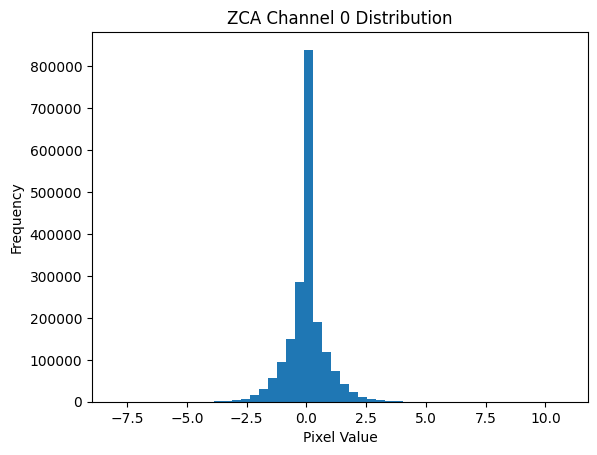

Channel 0 Mean: 4.6728074968599775e-09
Channel 0 Std: 0.7894800059684949


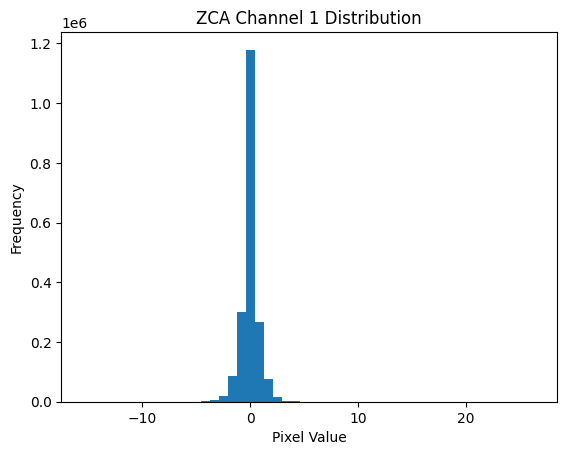

Channel 1 Mean: 1.0645021837406316e-08
Channel 1 Std: 0.77997776779423


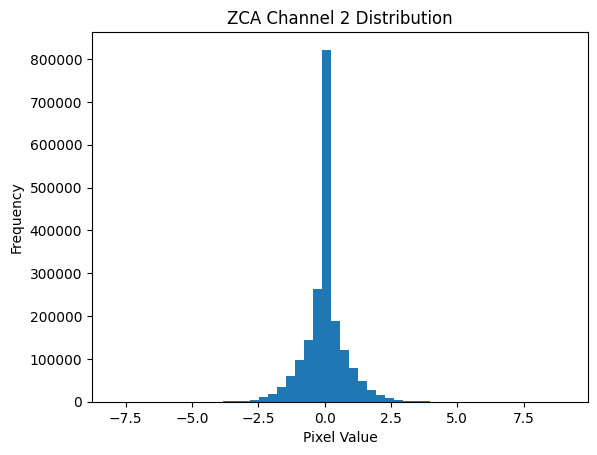

Channel 2 Mean: -3.733196976865798e-08
Channel 2 Std: 0.7710691879989057


In [ ]:
import matplotlib.pyplot as plt

for c in range(3):
    channel_data = patches_zca[:, :, :, c].flatten()

    plt.figure()
    plt.hist(channel_data, bins=50)
    plt.title(f"ZCA Channel {c} Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

    print(f"Channel {c} Mean:", np.mean(channel_data))
    print(f"Channel {c} Std:", np.std(channel_data))

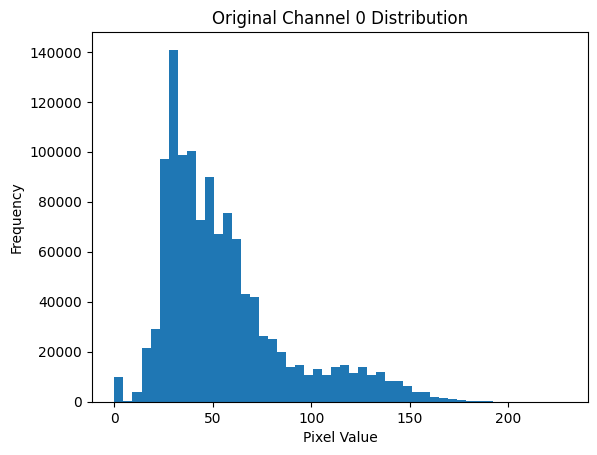

Channel 0 Mean: 55.61637071290368
Channel 0 Std: 32.144942879077796


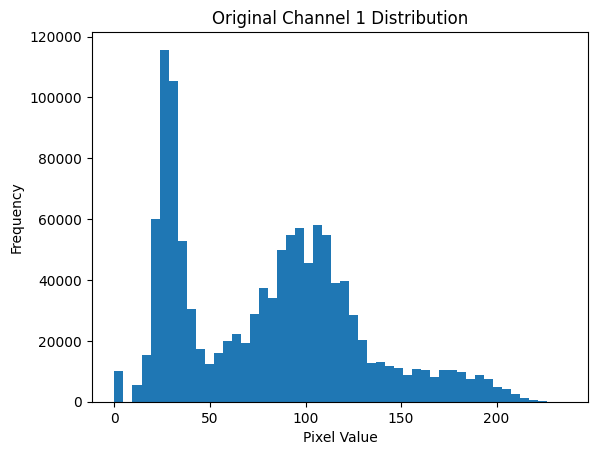

Channel 1 Mean: 81.2524766569634
Channel 1 Std: 47.76813383695788


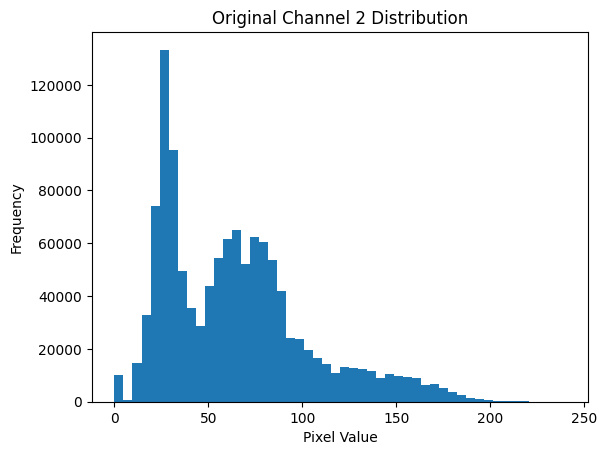

Channel 2 Mean: 64.34702415191879
Channel 2 Std: 39.13258899578853


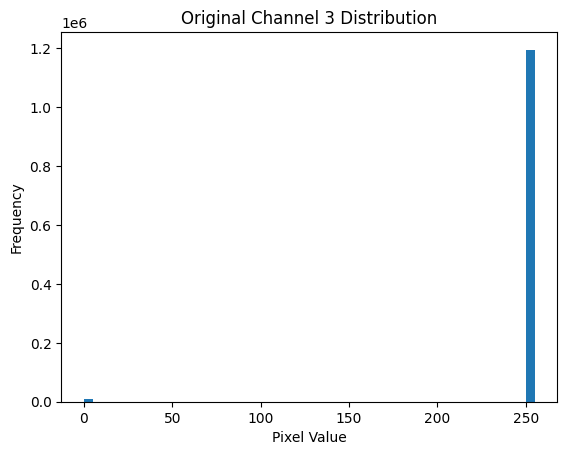

Channel 3 Mean: 252.88337653735343
Channel 3 Std: 23.13566268971458


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

all_channel_pixel_values = {0: [], 1: [], 2: [], 3: []}

for img_name in img_files:
    img_path = os.path.join(cwd, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        print(f"Warning: Could not load image {img_name}. Skipping.")
        continue

    if img.ndim == 2:
        img_4_channel = cv2.cvtColor(img, cv2.COLOR_GRAY2BGRA)
    elif img.shape[2] == 3:
        img_4_channel = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
    elif img.shape[2] == 4:
        img_4_channel = img
    else:
        print(f"Warning: Unexpected number of channels ({img.shape[2]}) in {img_name}. Skipping.")
        continue

    for c in range(4):
        all_channel_pixel_values[c].extend(img_4_channel[:, :, c].flatten())

for c in range(4):
    channel_data = np.array(all_channel_pixel_values[c])

    if len(channel_data) == 0:
        print(f"No data collected for Channel {c}. Skipping histogram.")
        continue

    plt.figure()
    plt.hist(channel_data, bins=50)
    plt.title(f"Original Channel {c} Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

    print(f"Channel {c} Mean:", np.mean(channel_data))
    print(f"Channel {c} Std:", np.std(channel_data))

Problem 3.2 Image Segmentation

In [63]:
import os
import cv2
import numpy as np
from scipy import ndimage
from skimage.measure import regionprops

!del /q output_results
input_folder = "soybeans_images"
output_folder = "output_results"
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.endswith((".JPG")):
        image = cv2.imread(os.path.join(input_folder, filename))
        original = image.copy()

        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        lower_green = np.array([35, 40, 40])
        upper_green = np.array([85, 255, 255])

        mask = cv2.inRange(hsv, lower_green, upper_green)

        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        labeled, num_features = ndimage.label(mask)

        regions = regionprops(labeled)

        regions = [r for r in regions if r.area > 50]

        regions = sorted(regions, key=lambda r: (r.bbox[0], r.bbox[1]))

        regions = sorted(regions, key=lambda r: r.area, reverse=True)[:36]

        regions = sorted(regions, key=lambda r: (r.bbox[0], r.bbox[1]))

        annotated = original.copy()

        for i, region in enumerate(regions):
            minr, minc, maxr, maxc = region.bbox

            cv2.rectangle(annotated,
                        (minc, minr),
                        (maxc, maxr),
                        (0, 0, 255),
                        2)

            cv2.putText(annotated,
                        str(i+1),
                        (minc, minr-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0, 0, 255),
                        2)

            crop = original[minr:maxr, minc:maxc]
            cv2.imwrite(os.path.join(output_folder,
                                    f"{os.path.basename(os.path.join(input_folder, filename)).split('.')[0]}_subplot_{i+1}.jpg"),
                        crop)

        cv2.imwrite(os.path.join(output_folder,
                                f"{os.path.basename(os.path.join(input_folder, filename)).split('.')[0]}_annotated.jpg"),
                    annotated)

/bin/bash: line 1: del: command not found
